 # Data Preparation

## Objetivo

Preparar os dados para modelagem, garantindo qualidade, consistência e estrutura adequada para análise de demanda e otimização de estoque.

Etapas:
- Tratamento de tipos de dados
- Tratamento de valores faltantes
- Criação de variáveis
- Construção de série temporal

## 2. Importação das Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sqlite3

from IPython.display import Markdown
from IPython.core.display import HTML
import math

import glob
import warnings
warnings.filterwarnings('ignore')

## 3. Configuraçãões Iniciais

In [2]:
# Cor principal do projeto
PRIMARY_COLOR = "#50e550"
SECONDARY_COLORS = sns.light_palette(PRIMARY_COLOR, n_colors=5)

# Estilo geral
sns.set_theme(style="whitegrid")

# Tamanho padrão
plt.rcParams['figure.figsize'] = (10, 6)

# Fonte
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

## 4. Carregamento e Leitura dos Dados



In [3]:
df = pd.read_parquet('../data/processed/df_analytics.parquet')

## 5. Visão Geral dos Dados

In [4]:
display(Markdown("### Primeiras linhas"))
display(df.head())

### Primeiras linhas

,order_id,order_item_id,product_id,seller_id,order_purchase_timestamp,order_status,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,...,product_height_cm,product_width_cm,customer_id,customer_unique_id,customer_city,customer_state,seller_city,seller_state,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-02 10:56:33,delivered,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,...,8.0,13.0,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,maua,SP,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-24 20:41:37,delivered,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,...,13.0,19.0,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA,belo horizonte,SP,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-08 08:38:49,delivered,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,...,19.0,21.0,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,guariba,SP,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-18 19:28:06,delivered,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,...,10.0,20.0,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,belo horizonte,MG,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-13 21:18:39,delivered,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,...,15.0,15.0,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,mogi das cruzes,SP,19.90,8.72


In [5]:
display(Markdown("### Informação das variáveis"))
df.info()

### Informação das variáveis

<class 'pandas.DataFrame'>
RangeIndex: 110197 entries, 0 to 110196
Data columns (total 23 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       110197 non-null  str    
 1   order_item_id                  110197 non-null  int64  
 2   product_id                     110197 non-null  str    
 3   seller_id                      110197 non-null  str    
 4   order_purchase_timestamp       110197 non-null  str    
 5   order_status                   110197 non-null  str    
 6   order_approved_at              110182 non-null  str    
 7   order_delivered_carrier_date   110195 non-null  str    
 8   order_delivered_customer_date  110189 non-null  str    
 9   order_estimated_delivery_date  110197 non-null  str    
 10  product_category_name          108660 non-null  str    
 11  product_weight_g               110179 non-null  float64
 12  product_length_cm              110179 non

In [6]:
display(Markdown("### Quantidade de valores únicos"))
df.nunique()

### Quantidade de valores únicos

order_id                         96478
order_item_id                       21
product_id                       32216
seller_id                         2970
order_purchase_timestamp         95956
order_status                         1
order_approved_at                88274
order_delivered_carrier_date     80106
order_delivered_customer_date    95658
order_estimated_delivery_date      445
product_category_name               73
product_weight_g                  2171
product_length_cm                   99
product_height_cm                  102
product_width_cm                    94
customer_id                      96478
customer_unique_id               93358
customer_city                     4085
customer_state                      27
seller_city                        595
seller_state                        22
price                             5859
freight_value                     6924
dtype: int64

In [7]:
display(Markdown("### Estátistica dos Dados"))
df.describe()

### Estátistica dos Dados

,order_item_id,product_weight_g,product_length_cm,product_height_cm,product_width_cm,price,freight_value
count,110197.000000,110179.000000,110179.000000,110179.000000,110179.000000,110197.000000,110197.000000
mean,1.198181,2089.680892,30.142541,16.555678,22.986604,119.980563,19.948598
std,0.706676,3741.605703,16.122277,13.409572,11.688439,182.299446,15.698136
min,1.000000,0.000000,7.000000,2.000000,6.000000,0.850000,0.000000
25%,1.000000,300.000000,18.000000,8.000000,15.000000,39.900000,13.080000
50%,1.000000,700.000000,25.000000,13.000000,20.000000,74.900000,16.260000
75%,1.000000,1800.000000,38.000000,20.000000,30.000000,134.170000,21.150000
max,21.000000,40425.000000,105.000000,105.000000,118.000000,6735.000000,409.680000


## 6. Análise de valores Faltantes

In [8]:
df.isnull().sum().sort_values(ascending=False)

product_category_name            1537
product_height_cm                  18
product_length_cm                  18
product_weight_g                   18
product_width_cm                   18
order_approved_at                  15
order_delivered_customer_date       8
order_delivered_carrier_date        2
order_purchase_timestamp            0
order_status                        0
product_id                          0
order_id                            0
order_item_id                       0
seller_id                           0
order_estimated_delivery_date       0
customer_id                         0
customer_unique_id                  0
customer_city                       0
customer_state                      0
seller_city                         0
seller_state                        0
price                               0
freight_value                       0
dtype: int64

### 6.1  Tratamento dos Dados Faltantes 

In [9]:
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': (df.isnull().sum() / len(df)) * 100
})

missing = missing.sort_values(by='missing_percent', ascending=False)

missing[missing['missing_percent'] > 0]

,missing_count,missing_percent
product_category_name,1537,1.394775
product_height_cm,18,0.016334
product_length_cm,18,0.016334
product_weight_g,18,0.016334
product_width_cm,18,0.016334
order_approved_at,15,0.013612
order_delivered_customer_date,8,0.007260
order_delivered_carrier_date,2,0.001815


> Valores faltantes em product_category_name representam 1,39% do dataset.

Devido ao baixo volume e impacto limitado na análise principal, optou-se pela remoção desses registros para garantir maior consistência dos dados.

> remover os demais dados faltantes poque representa menos de 0,01% do dataset.

In [10]:
df = df.dropna(subset=[
    'product_category_name',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'order_approved_at',
    'order_delivered_customer_date',
    'order_delivered_carrier_date'
])

## 7. Conversão de datas

In [11]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

In [12]:
df.dtypes

order_id                                    str
order_item_id                             int64
product_id                                  str
seller_id                                   str
order_purchase_timestamp         datetime64[us]
order_status                                str
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
product_category_name                       str
product_weight_g                        float64
product_length_cm                       float64
product_height_cm                       float64
product_width_cm                        float64
customer_id                                 str
customer_unique_id                          str
customer_city                               str
customer_state                              str
seller_city                                 str
seller_state                            

## 8. Feature Engineering

### Criação de Variáveis

### 8.1 - Custo total

In [13]:
df['total_cost'] = df['price'] + df['freight_value']

### 8.2 Volume do produto

In [14]:
df['product_volume_cm3'] = (
    df['product_length_cm'] *
    df['product_height_cm'] *
    df['product_width_cm']
)

### 8.3 Tempo de entrega

In [15]:
df['delivery_time_days'] = (
    df['order_delivered_customer_date'] - 
    df['order_purchase_timestamp']
).dt.days

In [16]:
df.head()

,order_id,order_item_id,product_id,seller_id,order_purchase_timestamp,order_status,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,...,customer_unique_id,customer_city,customer_state,seller_city,seller_state,price,freight_value,total_cost,product_volume_cm3,delivery_time_days
0,e481f51cbdc54678b7cc49136f2d6af7,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-02 10:56:33,delivered,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,...,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,maua,SP,29.99,8.72,38.71,1976.0,8
1,53cdb2fc8bc7dce0b6741e2150273451,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-24 20:41:37,delivered,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,...,af07308b275d755c9edb36a90c618231,barreiras,BA,belo horizonte,SP,118.70,22.76,141.46,4693.0,13
2,47770eb9100c2d0c44946d9cf07ec65d,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-08 08:38:49,delivered,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,...,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,guariba,SP,159.90,19.22,179.12,9576.0,9
3,949d5b44dbf5de918fe9c16f97b45f8a,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-18 19:28:06,delivered,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,...,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,belo horizonte,MG,45.00,27.20,72.20,6000.0,13
4,ad21c59c0840e6cb83a9ceb5573f8159,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-13 21:18:39,delivered,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,...,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,mogi das cruzes,SP,19.90,8.72,28.62,11475.0,2


## 9. Análise Exploratória de Dados (EDA)

Nesta etapa, analisamos a distribuição das variáveis principais para entender padrões, detectar outliers e validar a qualidade dos dados antes da modelagem.

### 9.1 Estatísticas descritivas

In [17]:
df[['price', 'freight_value', 'total_cost', 'product_volume_cm3', 'product_weight_g','delivery_time_days']].describe()

,price,freight_value,total_cost,product_volume_cm3,product_weight_g,delivery_time_days
count,108636.000000,108636.000000,108636.000000,108636.000000,108636.000000,108636.000000
mean,120.087161,19.982936,140.070097,15221.285697,2095.634725,12.002559
std,182.044245,15.733818,189.086851,23264.765858,3744.124300,9.439948
min,0.850000,0.000000,6.080000,168.000000,0.000000,0.000000
25%,39.900000,13.080000,55.240000,2856.000000,300.000000,6.000000
50%,74.900000,16.290000,92.125000,6552.000000,700.000000,10.000000
75%,134.900000,21.160000,157.730000,18375.000000,1800.000000,15.000000
max,6735.000000,409.680000,6929.310000,296208.000000,40425.000000,209.000000


### 9.2 Distribuição de preço

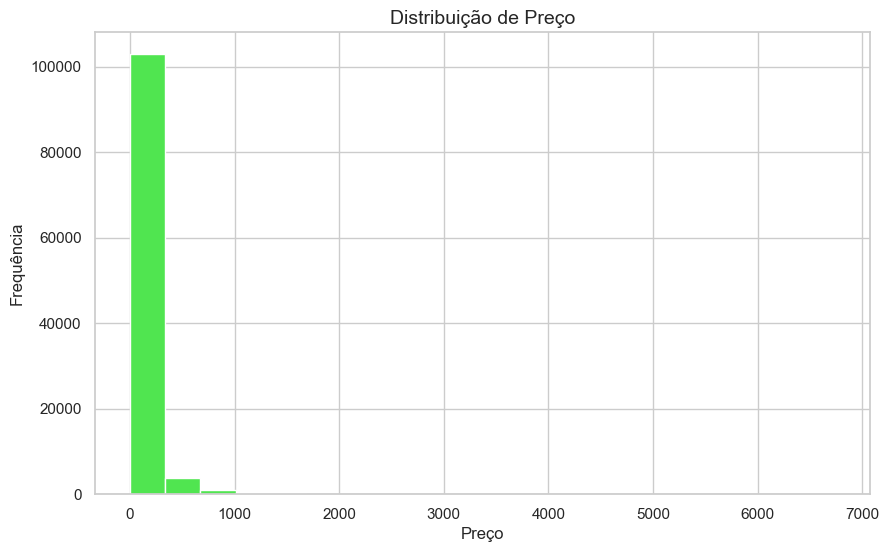

In [18]:
plt.figure()
df['price'].hist(bins=20, color=PRIMARY_COLOR)
plt.title('Distribuição de Preço')
plt.xlabel('Preço')
plt.ylabel('Frequência')
plt.show()

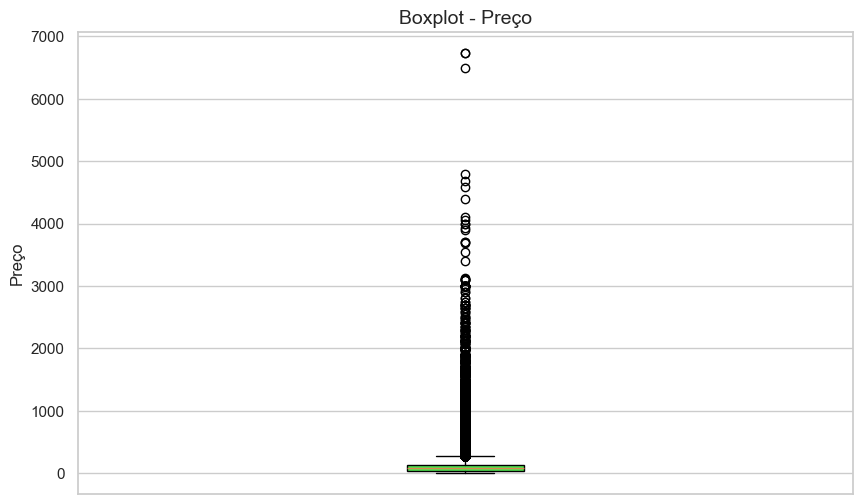

In [19]:
plt.figure()

plt.boxplot(
    df['price'],
    patch_artist=True,
    boxprops=dict(facecolor=PRIMARY_COLOR)
)


plt.xticks([]) 

plt.title('Boxplot - Preço')
plt.ylabel('Preço')

plt.show()

👉 Insight esperado:

- distribuição assimétrica (cauda longa)
- muitos produtos baratos, poucos caros
- possui outliers muito forte

### 9.3 Distribuição de Frete

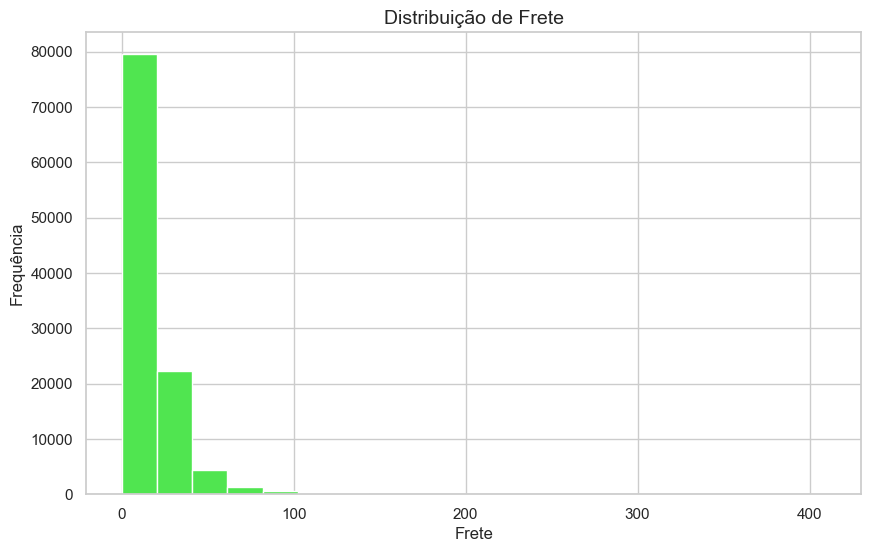

In [20]:
plt.figure()
df['freight_value'].hist(bins=20, color=PRIMARY_COLOR )
plt.title('Distribuição de Frete')
plt.xlabel('Frete')
plt.ylabel('Frequência')
plt.show()

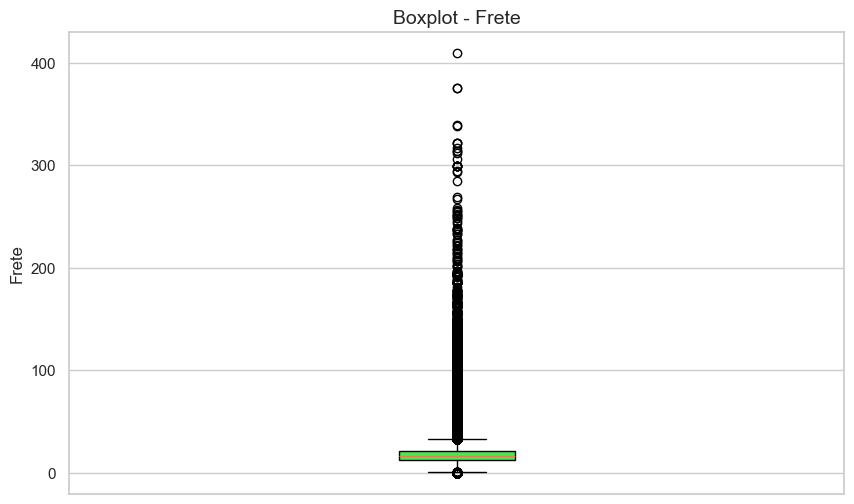

In [21]:
plt.figure()
plt.boxplot(
    df['freight_value'],
    patch_artist=True,
    boxprops=dict(facecolor=PRIMARY_COLOR)
    
)
plt.xticks([]) 
plt.title('Boxplot - Frete')
plt.ylabel('Frete')
plt.show()







👉 valores muito altos comparados ao padrão

outliers fortes

### 9.3 Custo Total

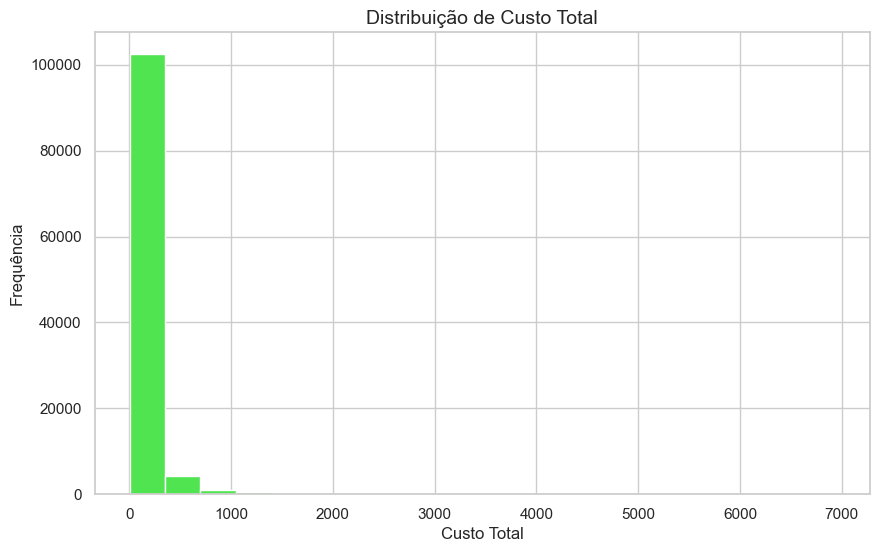

In [22]:
plt.figure()
df['total_cost'].hist(bins=20, color=PRIMARY_COLOR)
plt.title('Distribuição de Custo Total')
plt.xlabel('Custo Total')
plt.ylabel('Frequência')
plt.show()

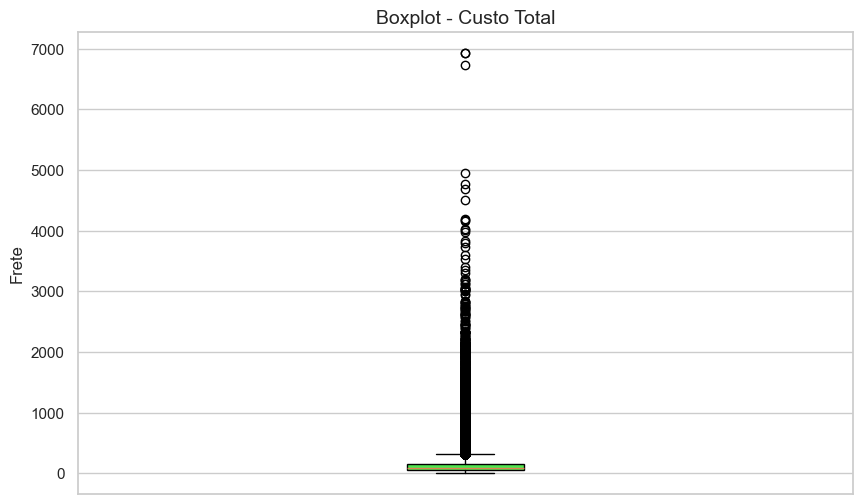

In [23]:
plt.figure()
plt.boxplot(
    df['total_cost'],
    patch_artist=True,
    boxprops=dict(facecolor=PRIMARY_COLOR)
)
plt.xticks([]) 
plt.title('Boxplot - Custo Total')
plt.ylabel('Frete')
plt.show()

👉 segue o mesmo padrão do preço

média: 140
max: 6929

👉 reforça presença de outliers

### 9.4 Volume 

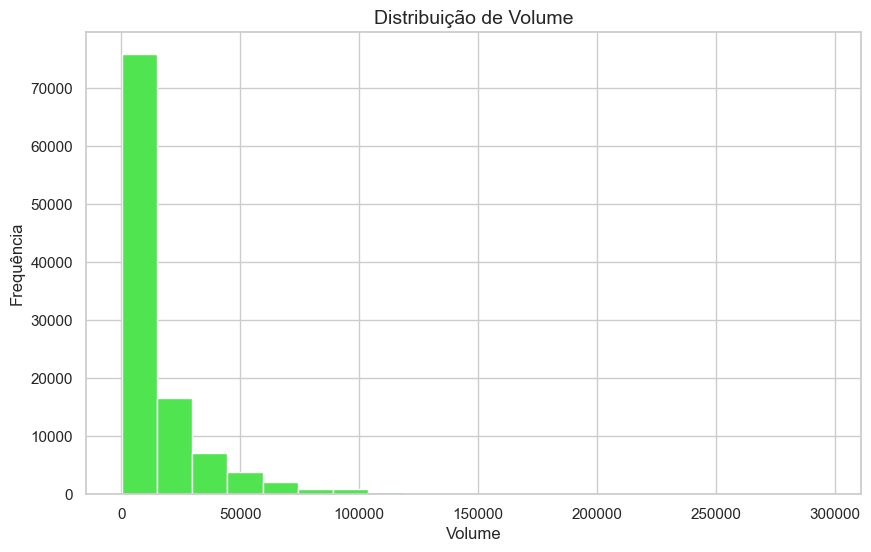

In [24]:
plt.figure()
df['product_volume_cm3'].hist(bins=20, color=PRIMARY_COLOR)
plt.title('Distribuição de Volume')
plt.xlabel('Volume')
plt.ylabel('Frequência')
plt.show()

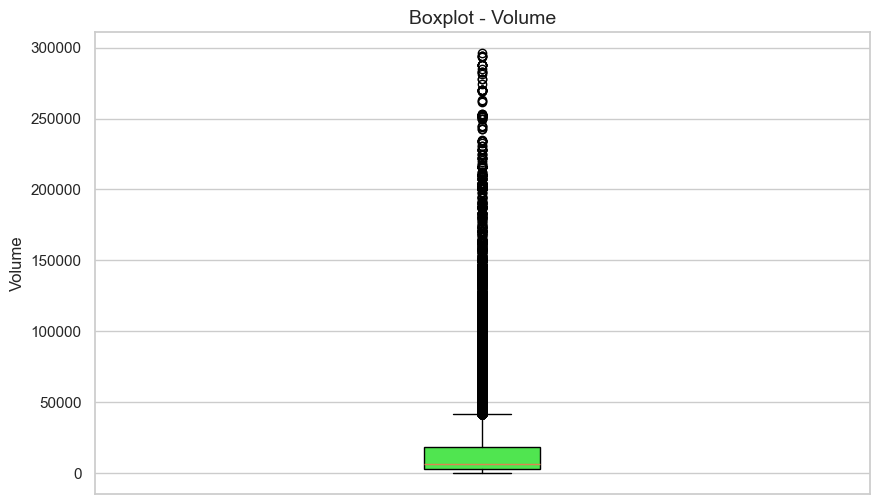

In [25]:
plt.figure()
plt.boxplot(
    df['product_volume_cm3'],
    patch_artist=True,
    boxprops=dict(facecolor=PRIMARY_COLOR)
)
plt.xticks([]) 
plt.title('Boxplot - Volume')
plt.ylabel('Volume')
plt.show()

### 9.5 Peso do Produto

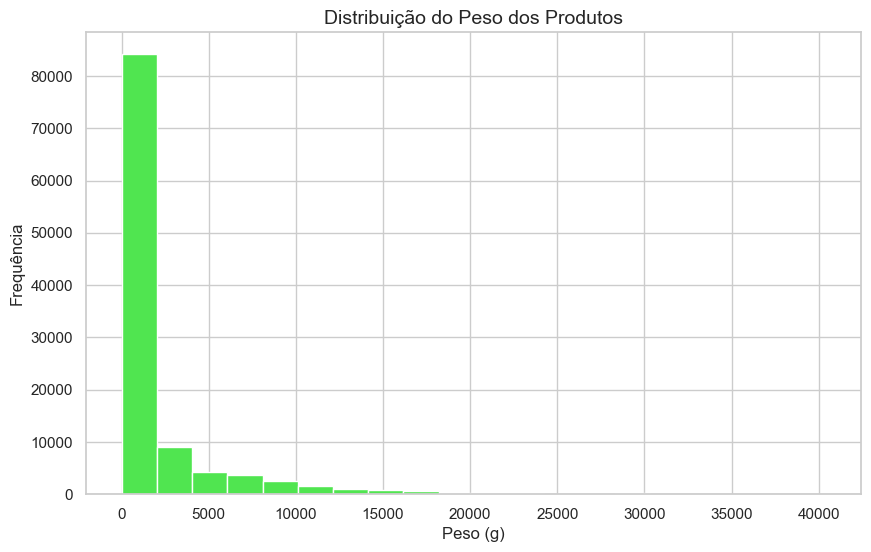

In [26]:


plt.figure()
df['product_weight_g'].hist(bins=20, color=PRIMARY_COLOR)
plt.title('Distribuição do Peso dos Produtos')
plt.xlabel('Peso (g)')
plt.ylabel('Frequência')
plt.show()

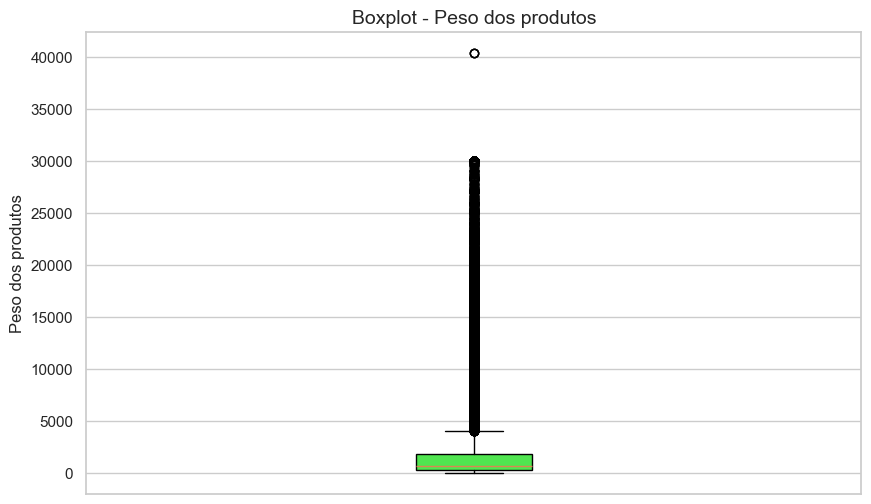

In [27]:
plt.figure()
plt.boxplot(
    df['product_weight_g'],
    patch_artist=True,
    boxprops=dict(facecolor=PRIMARY_COLOR)
)
plt.xticks([]) 
plt.title('Boxplot - Peso dos produtos')
plt.ylabel('Peso dos produtos')
plt.show()

### 9.6 Tempo de Entrega

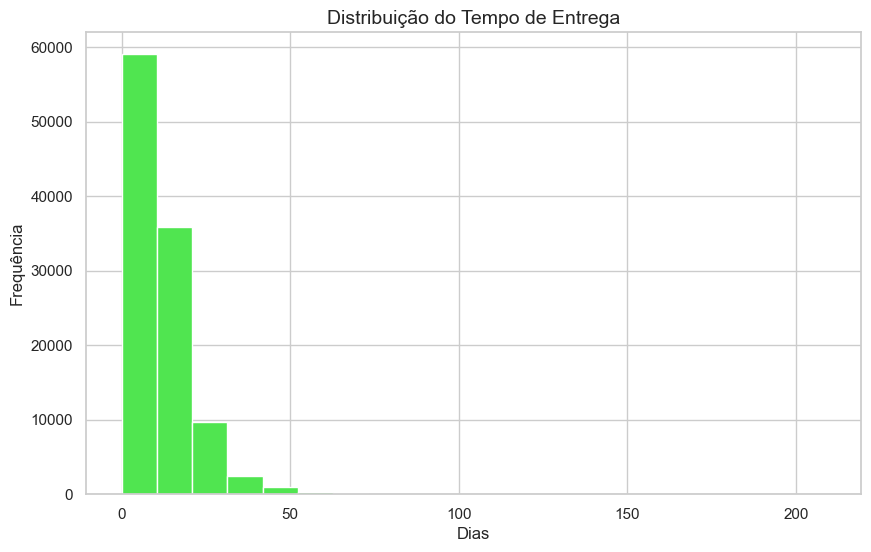

In [28]:
plt.figure()
df['delivery_time_days'].hist(bins=20, color=PRIMARY_COLOR)
plt.title('Distribuição do Tempo de Entrega')
plt.xlabel('Dias')
plt.ylabel('Frequência')
plt.show()

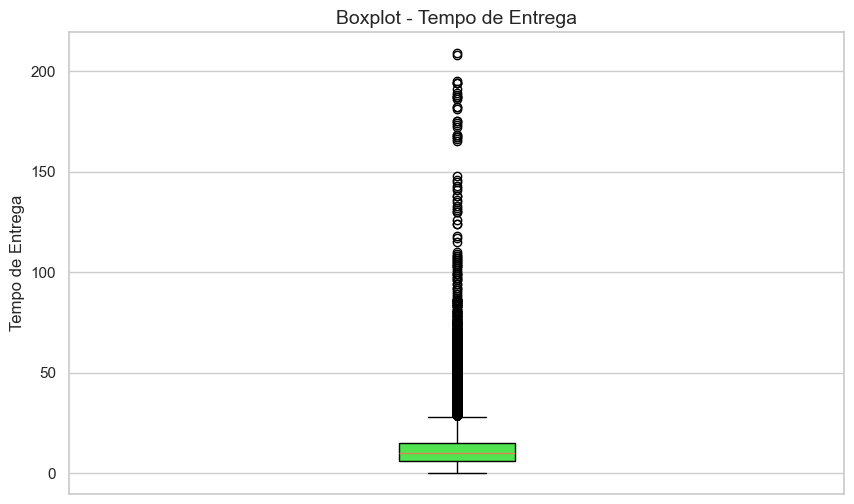

In [29]:
plt.figure()
plt.boxplot(
    df['delivery_time_days'],
    patch_artist=True,
    boxprops=dict(facecolor=PRIMARY_COLOR)
)
plt.xticks([]) 
plt.title('Boxplot - Tempo de Entrega')
plt.ylabel('Tempo de Entrega')
plt.show()

### 9.7 Top categorias de produtos

In [30]:
df['product_category_name'].value_counts().head(10)

product_category_name
cama_mesa_banho           10952
beleza_saude               9465
esporte_lazer              8428
moveis_decoracao           8156
informatica_acessorios     7643
utilidades_domesticas      6795
relogios_presentes         5857
telefonia                  4428
ferramentas_jardim         4267
automotivo                 4139
Name: count, dtype: int64

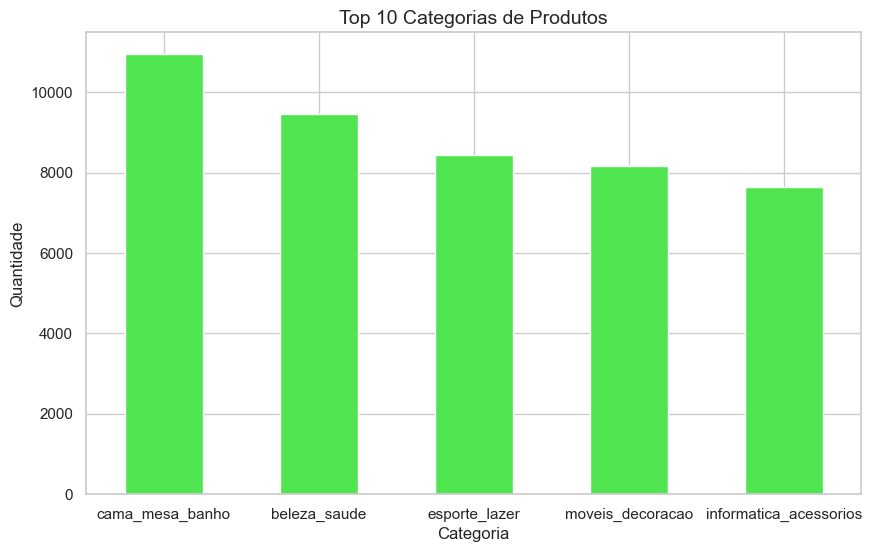

In [31]:
plt.figure()
df['product_category_name'].value_counts().head(5).plot(kind='bar', color=PRIMARY_COLOR)
plt.title('Top 10 Categorias de Produtos')
plt.xlabel('Categoria')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.show()

### 9.8 Distribuição por estado (clientes)

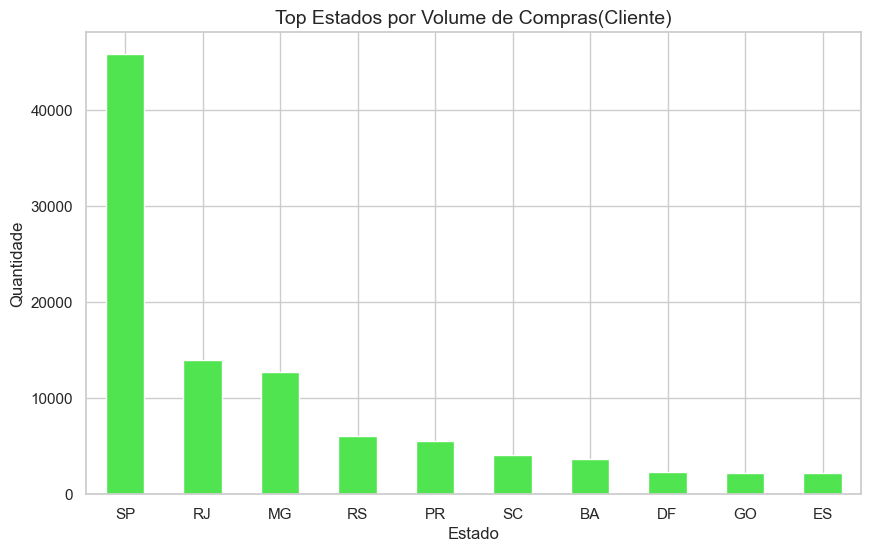

In [32]:
plt.figure()
df['customer_state'].value_counts().head(10).plot(kind='bar', color=PRIMARY_COLOR)
plt.title('Top Estados por Volume de Compras(Cliente)')
plt.xlabel('Estado')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.show()

### 9.9 Distribuição por estado (Vendedor)

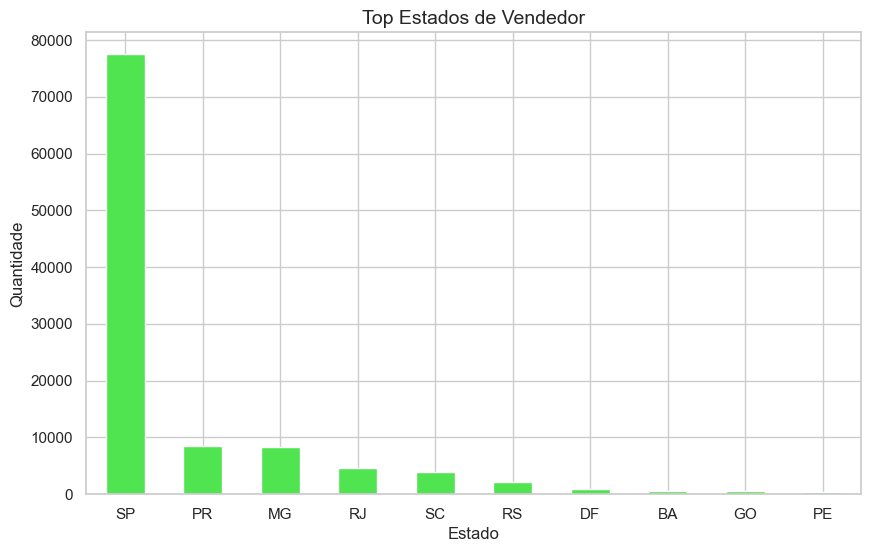

In [33]:
plt.figure()
df['seller_state'].value_counts().head(10).plot(kind='bar', color=PRIMARY_COLOR)
plt.title('Top Estados de Vendedor')
plt.xlabel('Estado')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.show()

### 9.10 Evolução temporal das vendas

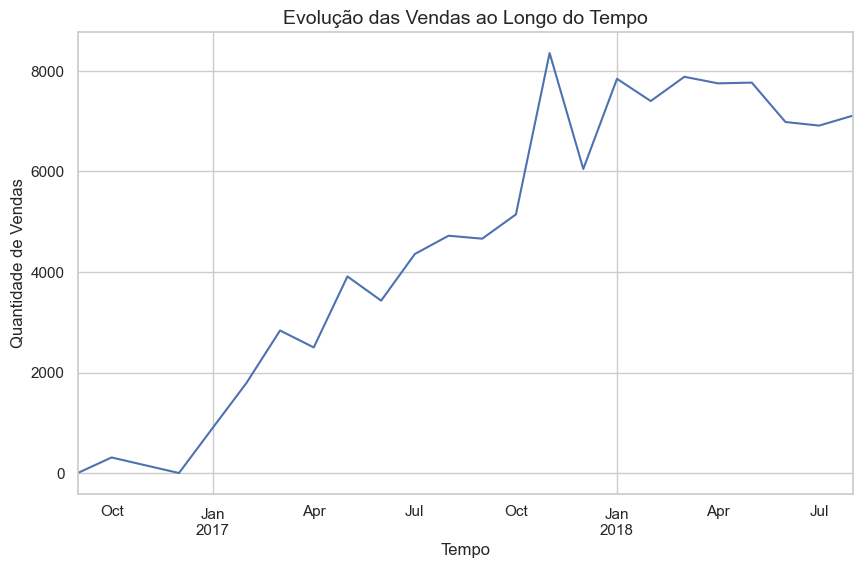

In [34]:
df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M')

sales_time = df.groupby('year_month').size()
sales_time.plot()
plt.title('Evolução das Vendas ao Longo do Tempo')
plt.xlabel('Tempo')
plt.ylabel('Quantidade de Vendas')
plt.show()

Os dados apresentam forte assimetria e presença de outliers, especialmente em preço, frete e tempo de entrega. Esses valores extremos podem distorcer modelos preditivos e foram tratados para garantir maior robustez das análises.

Além disso, observou-se grande variabilidade no tempo de entrega, indicando desafios logísticos que impactam diretamente a gestão de estoque e a experiência do cliente.

## 10. Tratar outliers nas variáveis

### 10.1 Variavel delivery_time_days

In [35]:
df = df[df['delivery_time_days'] < 60]

removido os valores muito alto

### 10.2 Variavel price

In [36]:
df = df[df['price'] < df['price'].quantile(0.99)]

### 10.3 Variavel freight_value

In [37]:
df = df[df['freight_value'] < df['freight_value'].quantile(0.99)]

## ⚠️ Tratamento de Outliers

Durante a análise exploratória, foram identificados valores extremos (outliers) nas variáveis de preço, frete e tempo de entrega.

Esses valores apresentam grande distorção em relação à distribuição dos dados, podendo representar:
- erros de registro
- casos muito raros
- condições logísticas atípicas

A presença desses outliers pode impactar negativamente a modelagem preditiva, gerando:
- viés nos modelos
- distorção na previsão de demanda
- decisões incorretas de estoque

### 🛠️ Estratégia adotada

Optou-se por aplicar filtros baseados em percentis e limites de negócio:

- Preço (`price`): remoção de valores acima do percentil 99
- Frete (`freight_value`): remoção de valores acima do percentil 99
- Tempo de entrega (`delivery_time_days`): remoção de valores acima de 60 dias

Essa abordagem permite:
- manter a maior parte dos dados representativos
- eliminar valores extremos que prejudicam a análise
- preservar o comportamento real do consumidor

### 🎯 Impacto esperado

Com o tratamento dos outliers, espera-se:
- maior robustez dos modelos preditivos
- melhor qualidade das previsões de demanda
- suporte mais confiável à tomada de decisão em estoque e supply chain

## 11. Criação da Base de Demanda



O objetivo desta etapa é transformar os dados transacionais em uma série temporal de vendas por produto, permitindo a modelagem preditiva da demanda.

A base de demanda representa a quantidade de vendas de cada produto ao longo do tempo.

### 11.1 Criar a variável data

In [38]:
df['date'] = df['order_purchase_timestamp'].dt.date

### 11.2 Criar demanda por produto

In [39]:
df_demand = (
    df.groupby(['product_id', 'date'])
      .size()
      .reset_index(name='sales')
)

In [40]:
df_demand.head()

,product_id,date,sales
0,00066f42aeeb9f3007548bb9d3f33c38,2018-05-20,1
1,00088930e925c41fd95ebfe695fd2655,2017-12-12,1
2,0009406fd7479715e4bef61dd91f2462,2017-12-21,1
3,000b8f95fcb9e0096488278317764d19,2018-08-01,1
4,000b8f95fcb9e0096488278317764d19,2018-08-10,1


In [41]:
df_demand.info()

<class 'pandas.DataFrame'>
RangeIndex: 89109 entries, 0 to 89108
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   product_id  89109 non-null  str   
 1   date        89109 non-null  object
 2   sales       89109 non-null  int64 
dtypes: int64(1), object(1), str(1)
memory usage: 4.8+ MB


### 11.3 Filtrar produtos com baixa recorrência

In [42]:
product_counts = df_demand['product_id'].value_counts()

valid_products = product_counts[product_counts > 10].index

df_demand = df_demand[df_demand['product_id'].isin(valid_products)]

In [43]:
## ordenar os dados 
df_demand = df_demand.sort_values(['product_id', 'date'])

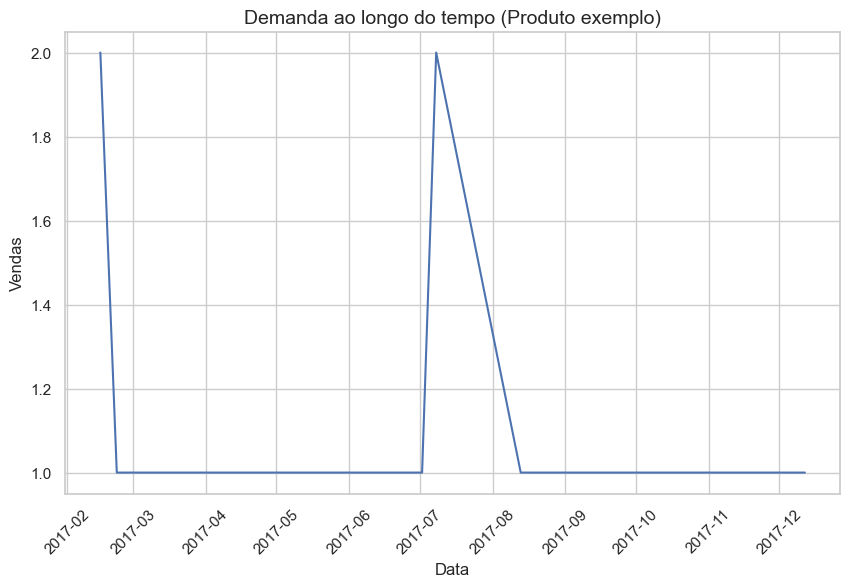

In [44]:
sample_product = df_demand['product_id'].iloc[10]

df_sample = df_demand[df_demand['product_id'] == sample_product]

import matplotlib.pyplot as plt

plt.figure()
plt.plot(df_sample['date'], df_sample['sales'])
plt.title('Demanda ao longo do tempo (Produto exemplo)')
plt.xlabel('Data')
plt.ylabel('Vendas')
plt.xticks(rotation=45)
plt.show()

### 11.4 Salaver Dataset 

In [45]:
df_demand.to_parquet('../data/processed/df_demand.parquet')

## 💡 Justificativa

A agregação dos dados por produto e data permite a construção de séries temporais, fundamentais para modelos de previsão de demanda.

Além disso, a remoção de produtos com baixa recorrência reduz o ruído nos dados e melhora a capacidade de generalização dos modelos preditivos.